# 06 — ML Models

Linear Regression (baseline) vs Random Forest Regressor comparison.
Evaluation uses MAE, RMSE and R2 metrics.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parents[1]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from Source.scripts.helpers import PROCESSED_DATA_DIR

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

In [2]:
df = pd.read_csv(PROCESSED_DATA_DIR / 'movies_merged.csv')

FEATURES = ['budget', 'runtime', 'release_year', 'primary_genre', 'decade']
TARGET   = 'revenue'

ml_df     = df[FEATURES + [TARGET]].dropna()
ml_encoded = pd.get_dummies(ml_df, columns=['primary_genre', 'decade'], drop_first=True)

X = ml_encoded.drop(columns=[TARGET])
y = ml_encoded[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')

Train: (4294, 32)  |  Test: (1074, 32)


## Helper Function — Compute Metrics

In [3]:
def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f'--- {name} ---')
    print(f'  MAE  : ${mae/1e6:>8.1f}M')
    print(f'  RMSE : ${rmse/1e6:>8.1f}M')
    print(f'  R2   :  {r2:>8.4f}')
    return {'model': name, 'MAE_M': mae/1e6, 'RMSE_M': rmse/1e6, 'R2': r2}

## Model 1 — Linear Regression (Baseline)

The simplest model. How much of the budget–revenue relationship can a linear model explain?
Scaling is required because features are on different scales.

In [4]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

result_lr = evaluate('Linear Regression', y_test, y_pred_lr)

--- Linear Regression ---
  MAE  : $    62.0M
  RMSE : $   123.5M
  R2   :    0.5313


## Model 2 — Random Forest Regressor

Captures non-linear relationships and produces feature importance scores.
Does not require scaling — tree-based model.

In [5]:
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

result_rf = evaluate('Random Forest', y_test, y_pred_rf)

--- Random Forest ---
  MAE  : $    60.8M
  RMSE : $   122.1M
  R2   :    0.5419


## Model Comparison

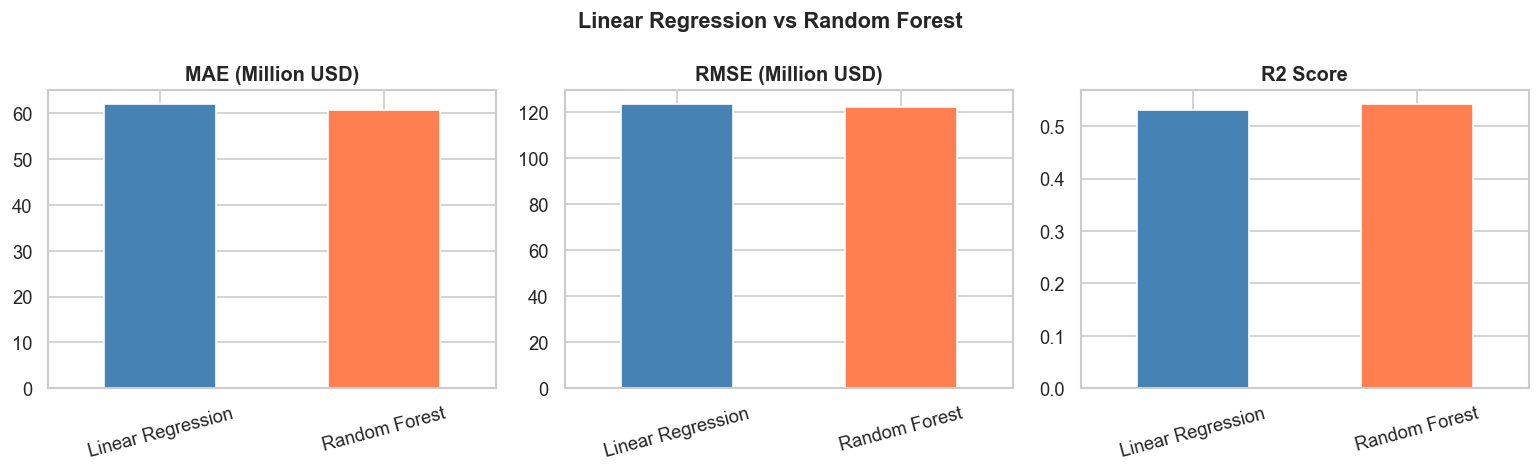

                   MAE_M   RMSE_M     R2
model                                   
Linear Regression  62.04  123.532  0.531
Random Forest      60.78  122.126  0.542


In [6]:
results = pd.DataFrame([result_lr, result_rf]).set_index('model')

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
colors = ['steelblue', 'coral']

for ax, col, label in zip(axes,
    ['MAE_M', 'RMSE_M', 'R2'],
    ['MAE (Million USD)', 'RMSE (Million USD)', 'R2 Score']):
    results[col].plot(kind='bar', ax=ax, color=colors, edgecolor='white')
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Linear Regression vs Random Forest', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print(results.round(3))

**Interpretation:** Random Forest only marginally outperformed Linear Regression: RMSE difference $1.4M (1.1% improvement). Results — LR: MAE $62.0M, RMSE $123.5M, R² = 0.531 | RF: MAE $60.8M, RMSE $122.1M, R² = 0.542. This closeness is not coincidental: EDA already showed a strong linear relationship (r = 0.70), so the non-linear capacity RF adds makes little difference here. The high RMSE ($122M) stems from outliers — a handful of blockbuster revenues are far above average and both models struggle to predict them.

## Feature Importance (Random Forest)

Which feature plays the most decisive role in predicting revenue?

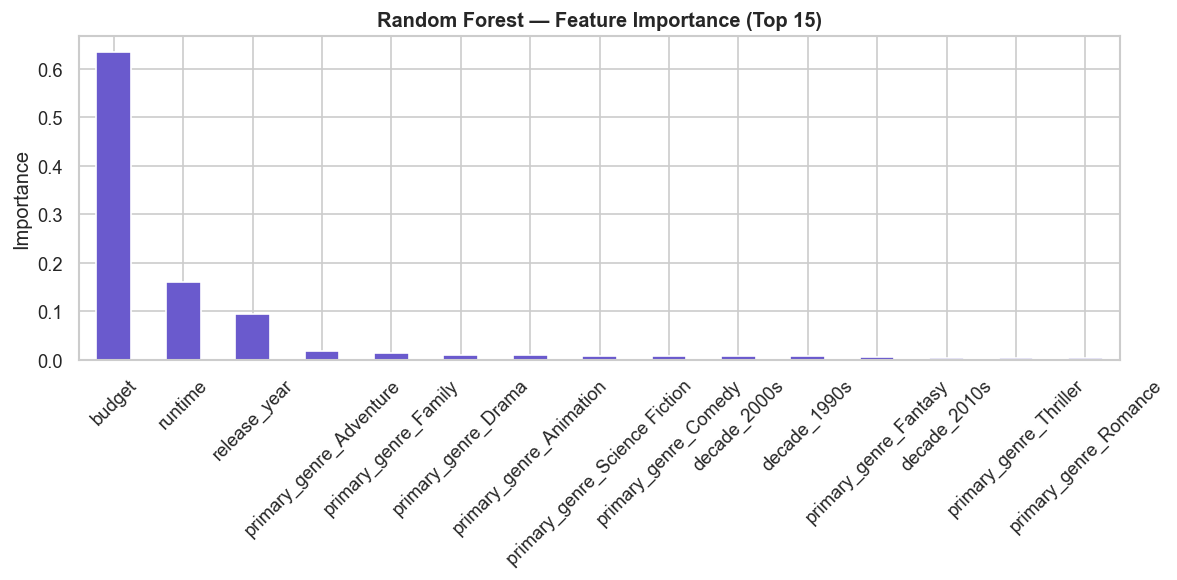

budget                           0.635589
runtime                          0.160890
release_year                     0.094796
primary_genre_Adventure          0.018141
primary_genre_Family             0.014308
primary_genre_Drama              0.009657
primary_genre_Animation          0.009503
primary_genre_Science Fiction    0.007492
primary_genre_Comedy             0.007368
decade_2000s                     0.007337
decade_1990s                     0.007305
primary_genre_Fantasy            0.004987
decade_2010s                     0.004164
primary_genre_Thriller           0.003253
primary_genre_Romance            0.003202
dtype: float64


In [7]:
fi = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 5))
fi.plot(kind='bar', ax=ax, color='slateblue', edgecolor='white')
ax.set_title('Random Forest — Feature Importance (Top 15)', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Importance')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()
print(fi)

**Interpretation:** `budget` alone carries **63.6%** of feature importance — confirming the EDA correlation finding. A distant second is `runtime` (16.1%), followed by `release_year` (9.5%). All genre and decade variables combined remain below 10%. This distribution clearly shows that budget is the dominant predictor of revenue, with other features playing a secondary corrective role.

## Actual vs Predicted

Ideal model: all points fall on the diagonal line.

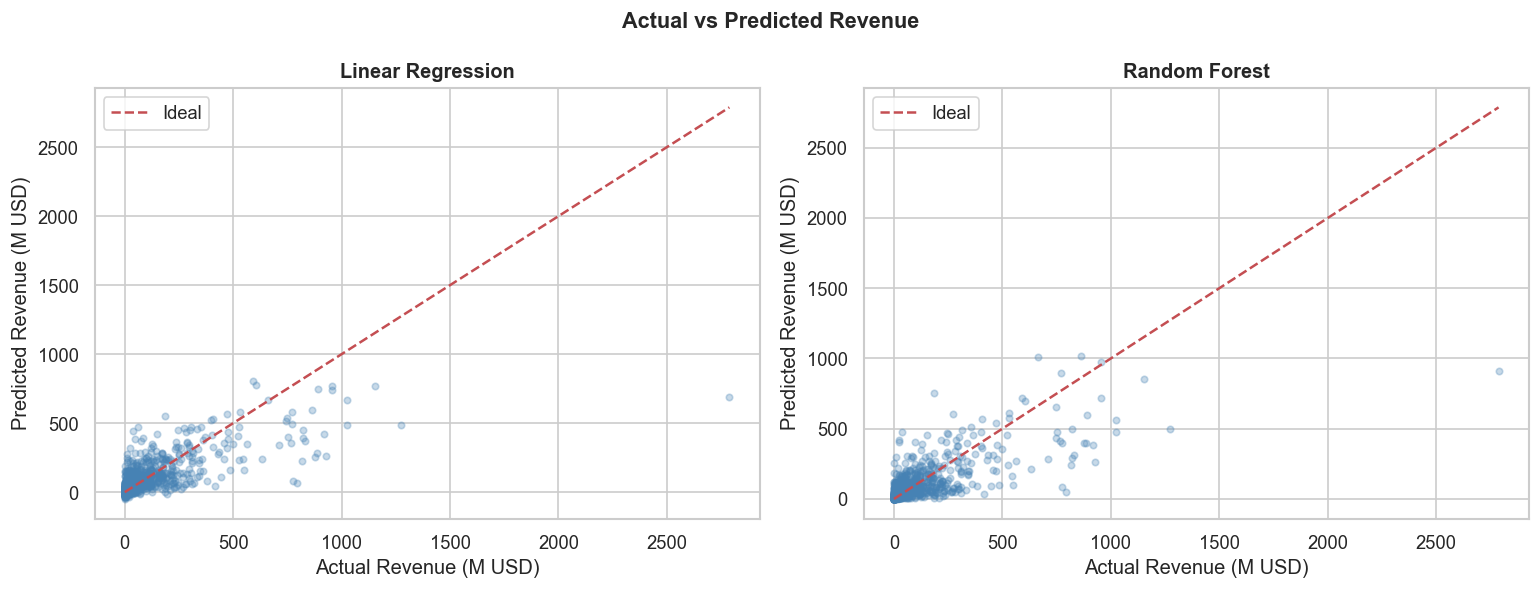

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, preds, name in zip(axes,
    [y_pred_lr, y_pred_rf],
    ['Linear Regression', 'Random Forest']):
    ax.scatter(y_test / 1e6, preds / 1e6, alpha=0.3, s=15, color='steelblue')
    lim = max(y_test.max(), max(preds)) / 1e6
    ax.plot([0, lim], [0, lim], 'r--', linewidth=1.5, label='Ideal')
    ax.set_xlabel('Actual Revenue (M USD)')
    ax.set_ylabel('Predicted Revenue (M USD)')
    ax.set_title(name, fontweight='bold')
    ax.legend()

plt.suptitle('Actual vs Predicted Revenue', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()